In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.interpolate import RBFInterpolator
from scipy.optimize import root_scalar

In [2]:
# Apply Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 11  # Must be odd
polyorder = 3

In [3]:
raw_df = pd.read_csv(
    "experiment_data.csv", 
    delimiter='\t', 
    names=['client_labda','server_mu', 'alpha', 'active_servers_num', 'run_iterations', 'request_id', 'server_processing_time_ideal', 
           'time_untill_next_client', 'sent_is_cpu','client_measured_time','server_processing_time_measured', 'is_cpu_received'], 
    header=None
)
raw_df.head()

,client_labda,server_mu,alpha,active_servers_num,run_iterations,request_id,server_processing_time_ideal,time_untill_next_client,sent_is_cpu,client_measured_time,server_processing_time_measured,is_cpu_received
0,0.3,1,0.1,1,500,0,0.617761,0.246800,0,623.0,0.618305,0.0
1,0.3,1,0.1,1,500,1,0.570009,0.125432,0,1054.0,0.570570,0.0
2,0.3,1,0.1,1,500,2,0.248522,0.005538,0,1288.0,0.248974,0.0
3,0.3,1,0.1,1,500,3,0.578565,0.505948,0,1358.0,0.579098,0.0
4,0.3,1,0.1,1,500,4,0.112288,0.157745,0,1298.0,0.112846,0.0


In [4]:
print(f"NO RESULT WAS SENT FOR - {sum(raw_df['sent_is_cpu']!=raw_df['is_cpu_received'])} requests")

NO RESULT WAS SENT FOR - 187 requests


## Data cleaning

In [5]:
received_results_df = raw_df[raw_df['sent_is_cpu']==raw_df['is_cpu_received']].copy()

In [6]:
received_results_df = received_results_df[received_results_df['run_iterations'] == 500]

In [7]:
received_results_df.info()

<class 'pandas.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 12 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   client_labda                     float64
 1   server_mu                        int64  
 2   alpha                            float64
 3   active_servers_num               int64  
 4   run_iterations                   int64  
 5   request_id                       int64  
 6   server_processing_time_ideal     float64
 7   time_untill_next_client          float64
 8   sent_is_cpu                      int64  
 9   client_measured_time             float64
 10  server_processing_time_measured  float64
 11  is_cpu_received                  float64
dtypes: float64(7), int64(5)
memory usage: 503.6 MB


## Convert to appropreate datatypes for mem-footprint reduction

In [8]:
# Convert categorical datatypes
received_results_df['client_labda'] = received_results_df['client_labda'].astype('category')
received_results_df['server_mu'] = received_results_df['server_mu'].astype('category')
received_results_df['alpha'] = received_results_df['alpha'].astype('category')

# Convert Integers datatypes
received_results_df['is_cpu_received'] = received_results_df['is_cpu_received'].astype('int64')

# Convert boolean datatypes
received_results_df['sent_is_cpu'] = received_results_df['sent_is_cpu'].astype('bool')

# Convert miliseconds to seconds
MILISECONDS_IN_SECOND = 1000
received_results_df['client_measured_time'] = received_results_df['client_measured_time'] / MILISECONDS_IN_SECOND

In [9]:
# The is_cpu flag must be the same sent_flat==recived_flag
assert(sum(received_results_df['sent_is_cpu'] != received_results_df['is_cpu_received']) == 0)

In [10]:
received_results_df = received_results_df.drop(['is_cpu_received'], axis=1)

In [11]:
received_results_df.info()

<class 'pandas.DataFrame'>
Index: 5077826 entries, 0 to 5078012
Data columns (total 11 columns):
 #   Column                           Dtype   
---  ------                           -----   
 0   client_labda                     category
 1   server_mu                        category
 2   alpha                            category
 3   active_servers_num               int64   
 4   run_iterations                   int64   
 5   request_id                       int64   
 6   server_processing_time_ideal     float64 
 7   time_untill_next_client          float64 
 8   sent_is_cpu                      bool    
 9   client_measured_time             float64 
 10  server_processing_time_measured  float64 
dtypes: bool(1), category(3), float64(4), int64(3)
memory usage: 329.3 MB


## Investigation of truthness

In [12]:
investigate_df = received_results_df.groupby(['alpha', 'active_servers_num'], observed=False)[
    ["server_processing_time_ideal", "server_processing_time_measured", "client_measured_time"]
].mean()

investigate_df = investigate_df.dropna(axis=0, how='all')
investigate_df = investigate_df.reset_index()
investigate_df['alpha'] = investigate_df['alpha'].astype('float64')
investigate_df = investigate_df[investigate_df['alpha'].isin({0.0, 0.2, 0.4, 0.6, 0.8, 1.0})]
investigate_df = investigate_df[(investigate_df['active_servers_num'] > 20) & (investigate_df['active_servers_num'] < 694)]
investigate_df

,alpha,active_servers_num,server_processing_time_ideal,server_processing_time_measured,client_measured_time
20,0.0,21,0.954284,0.954998,1.116252
21,0.0,22,1.001952,1.002723,1.199862
22,0.0,23,1.000461,1.001177,1.151056
23,0.0,24,1.022919,1.023575,1.176098
24,0.0,25,0.985568,0.986301,1.127192
...,...,...,...,...,...
5378,1.0,689,0.976179,1.215785,1.240089
5379,1.0,690,1.032479,1.259932,1.297202
5380,1.0,691,1.025053,1.229601,1.249569
5381,1.0,692,1.045300,1.280784,1.321376


In [13]:
LAMBDA = 0.3

def erlang_c(n, rho):
    """Erlang-C probability that an arriving customer queues."""
    # rho = lambda / (n * mu)
    if rho >= 1.0:
        return 1.0
    # compute sum_{i=0}^{n-1} (n*rho)^i / i!
    terms = np.empty(n)
    terms[0] = 1.0
    for i in range(1, n):
        terms[i] = terms[i-1] * (n * rho) / i
    sum_terms = np.sum(terms)
    last_term = terms[-1] * (n * rho) / n   # (n*rho)^n / n!
    C = last_term / (sum_terms * (1 - rho) + last_term)
    return C

def mean_response_time(mu, n):
    """M/M/n mean system time."""
    if mu <= LAMBDA / n:
        return np.inf
    rho = LAMBDA / (n * mu)
    C = erlang_c(n, rho)
    T = 1.0 / mu + C / (n * mu - LAMBDA)
    return T

def solve_mu(target_T, n):
    """Return mu such that mean_response_time(mu, n) == target_T."""
    # Lower bound: just above stability limit
    low = LAMBDA / n + 1e-12
    # Find an upper bound by doubling until T(mu) < target_T
    high = 1.0
    while mean_response_time(high, n) > target_T:
        high *= 2.0
        if high > 1e6:  # safety valve
            raise ValueError("No valid mu found in reasonable range")
    # Bisection
    for _ in range(100):
        mid = (low + high) / 2.0
        T_mid = mean_response_time(mid, n)
        if T_mid > target_T:
            low = mid
        else:
            high = mid
        if high - low < 1e-12:
            break
    return (low + high) / 2.0

# Group by n and alpha, compute mean measured time
grouped = investigate_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean()

mu_dict = {}
for (n, alpha), T_mean in grouped.items():
    # Ensure n is int
    n = int(n)
    try:
        mu = solve_mu(T_mean, n)
        mu_dict[(n, alpha)] = mu
    except ValueError as e:
        print(f"Failed for n={n}, alpha={alpha}: {e}")

# mu_dict now contains the inferred service rates

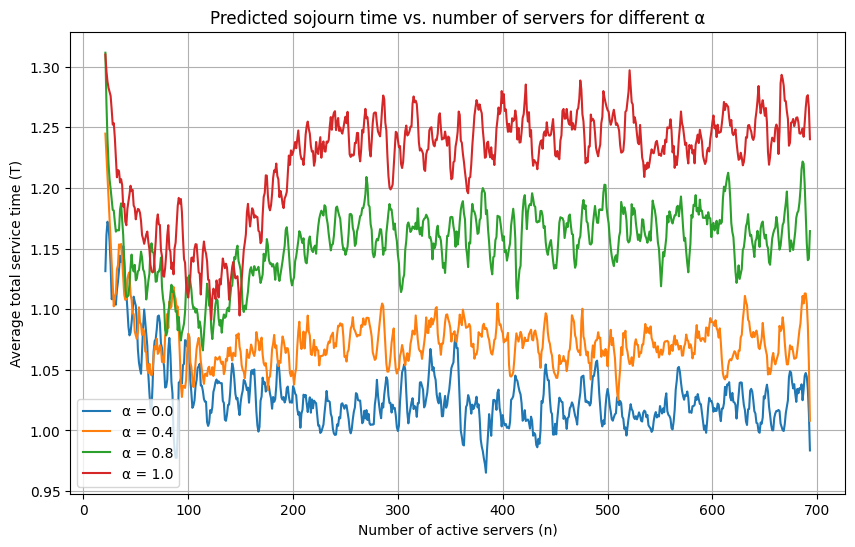

In [14]:
from scipy.interpolate import interp1d

# Reuse the functions from the previous code (erlang_c, mean_response_time)
LAMBDA = 0.3
target_alphas = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Build interpolators for each alpha
interpolators = {}
for alpha in target_alphas:
    points = []
    for (n, a), mu in mu_dict.items():
        if abs(a - alpha) < 1e-9:          # exact match (adjust tolerance if needed)
            points.append((n, mu))
    if not points:
        print(f"No data for α = {alpha}, skipping.")
        continue
    points.sort(key=lambda x: x[0])
    n_vals = np.array([p[0] for p in points])
    mu_vals = np.array([p[1] for p in points])
    # Linear interpolation (use kind='cubic' for smoothness if enough points)
    f = interp1d(n_vals, mu_vals, kind='linear', fill_value='extrapolate')
    interpolators[alpha] = (n_vals.min(), n_vals.max(), f)

# Evaluate T for n = 21 .. 693
n_range = np.arange(21, 694)
plt.figure(figsize=(10, 6))

for alpha, (n_min, n_max, f) in interpolators.items():
    if alpha in {0.0, 0.4, 0.8, 1.0}:
        T_values = np.full_like(n_range, np.nan, dtype=float)
        for i, n in enumerate(n_range):
            # Optional: restrict to interpolation range to avoid wild extrapolations
            if n < n_min or n > n_max:
                continue
            mu = f(n)
            if mu > LAMBDA / n:                # stability condition
                T_values[i] = mean_response_time(mu, n)

        y_predicted = savgol_filter(T_values, window_length, polyorder)
        plt.plot(n_range, y_predicted, label=f'α = {alpha}')

plt.xlabel('Number of active servers (n)')
plt.ylabel('Average total service time (T)')
plt.title('Predicted sojourn time vs. number of servers for different α')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
def average_difference(v1, v2):
    """
    Calculate the average absolute difference between two vectors.
    
    Parameters
    ----------
    v1, v2 : array-like
        Input vectors (lists, tuples, numpy arrays) of equal length.
    
    Returns
    -------
    float
        mean(|v1[i] - v2[i]|)
    
    Raises
    ------
    ValueError
        If the vectors have different lengths.
    """
    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)
    if v1.shape != v2.shape:
        raise ValueError("v1 and v2 must have the same length")
    return np.mean(np.abs(v1 - v2))

In [16]:
# from math import factorial
from scipy.interpolate import interp1d

LAMBDA = 0.3

# ----------------------------------------------------------------------
# 1. Build mu-interpolators from mu_dict (key: (n, alpha) -> mu)
# ----------------------------------------------------------------------
def build_interpolators(mu_dict):
    """Return dict: alpha -> (n_min, n_max, interp_function)"""
    interpolators = {}
    for (n, alpha), mu in mu_dict.items():
        interpolators.setdefault(alpha, []).append((n, mu))
    result = {}
    for alpha, points in interpolators.items():
        points.sort(key=lambda x: x[0])
        n_vals = np.array([p[0] for p in points])
        mu_vals = np.array([p[1] for p in points])
        f = interp1d(n_vals, mu_vals, kind='linear',
                     bounds_error=False, fill_value=(mu_vals[0], mu_vals[-1]))
        result[alpha] = (n_vals.min(), n_vals.max(), f)
    return result

# Create the interpolators once (mu_dict must be defined before)
mu_interpolators = build_interpolators(mu_dict)

def get_mu(n, alpha):
    """Interpolated service rate for a given (n, alpha)."""
    if alpha not in mu_interpolators:
        raise ValueError(f"No data for alpha={alpha}")
    n_min, n_max, f = mu_interpolators[alpha]
    if n < n_min or n > n_max:
        raise ValueError(f"n={n} out of measured range [{n_min}, {n_max}] for alpha={alpha}")
    return float(f(n))

# ----------------------------------------------------------------------
# 2. Model functions (homogeneous μ(n,α,i) = μ(n,α))
# ----------------------------------------------------------------------
def p0(n, alpha):
    """Steady-state probability of empty system."""
    mu = get_mu(n, alpha)
    if n * mu <= LAMBDA:
        raise ValueError(f"System unstable: n*mu <= lambda for n={n}, alpha={alpha}")
    # sum_{i=1}^n lambda^i / (i! * mu^i)
    sum1 = 0.0
    term = 1.0  # will build lambda^i/(i! mu^i) iteratively
    for i in range(1, n + 1):
        term *= LAMBDA / (i * mu)   # term = lambda^i / (i! mu^i)
        sum1 += term
    # term2 = lambda^{n+1} / (n! * mu^n * (n*mu - lambda))
    # term (after loop) is lambda^n/(n! mu^n)
    term2 = term * LAMBDA / (n * mu - LAMBDA)   # lambda^{n+1}/(n! mu^n (n mu - lambda))
    return 1.0 / (1.0 + sum1 + term2)

def pk(k, n, alpha):
    """Probability of exactly k customers in the system."""
    if k < 0:
        return 0.0
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    if k <= n:
        # lambda^k / (k! * mu^k) * p0
        # compute iteratively
        val = 1.0
        for i in range(1, k + 1):
            val *= LAMBDA / (i * mu)
        return val * p0_val
    else:
        # lambda^k / (n! * mu^n * (n*mu)^{k-n}) * p0
        # base: lambda^n/(n! mu^n)
        base = 1.0
        for i in range(1, n + 1):
            base *= LAMBDA / (i * mu)
        # multiply by (lambda/(n*mu))^{k-n}
        extra = (LAMBDA / (n * mu)) ** (k - n)
        return base * extra * p0_val

def pQ(n, alpha):
    """Probability that an arriving customer has to queue (Erlang-C)."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    # term = lambda^{n+1} / (n! * mu^n * (n*mu - lambda))
    # compute base lambda^n/(n! mu^n)
    base = 1.0
    for i in range(1, n + 1):
        base *= LAMBDA / (i * mu)
    term = base * LAMBDA / (n * mu - LAMBDA)
    return term * p0_val

def L_N(n, alpha):
    """Partial sum (as defined in the question): first n terms of L plus extra."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    # sum_{k=1}^{n} k * lambda^k / (k! mu^k)
    sum1 = 0.0
    term = 1.0  # lambda^k/(k! mu^k)
    for k in range(1, n + 1):
        term *= LAMBDA / (k * mu)
        sum1 += k * term
    # second term: lambda^{n+1} / ((n-1)! * mu^n * (n mu - lambda))
    # compute (n-1)! and lambda^n/( (n-1)! mu^{n-1} )? Let's use factorial:
    second = (LAMBDA ** (n + 1)) / (factorial(n - 1) * (mu ** n) * (n * mu - LAMBDA))
    return (sum1 + second) * p0_val

def L_Q(n, alpha):
    """Mean number of customers in queue."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    # formula: mu * lambda^{n+1} / ((n-1)! * mu^n * (n*mu - lambda)^2) * p0
    num = mu * (LAMBDA ** (n + 1))
    den = factorial(n - 1) * (mu ** n) * ((n * mu - LAMBDA) ** 2)
    return num / den * p0_val

def L_sys(n, alpha):
    """Mean number of customers in system (L)."""
    mu = get_mu(n, alpha)
    p0_val = p0(n, alpha)
    # sum_{k=1}^{n} k * lambda^k / (k! mu^k)
    sum1 = 0.0
    term = 1.0
    for k in range(1, n + 1):
        term *= LAMBDA / (k * mu)
        sum1 += k * term
    # second part: lambda^{n+1} / ((n-1)! mu^n (n mu - lambda)) * (1 + mu/(n mu - lambda))
    base = (LAMBDA ** (n + 1)) / (factorial(n - 1) * (mu ** n) * (n * mu - LAMBDA))
    second = base * (1.0 + mu / (n * mu - LAMBDA))
    return (sum1 + second) * p0_val

def T_sys(n, alpha):
    """Mean sojourn time in system."""
    return L_sys(n, alpha) / LAMBDA


In [17]:
n, alpha = 50, 0.4
print(f"p0  = {p0(n, alpha):.6f}")
print(f"pQ  = {pQ(n, alpha):.6f}")
print(f"L_Q = {L_Q(n, alpha):.4f}")
print(f"L   = {L_sys(n, alpha):.4f}")
print(f"T   = {T_sys(n, alpha):.4f}")

p0  = 0.715803
pQ  = 0.000000
L_Q = 0.0000
L   = 0.3344
T   = 1.1145


In [18]:
def plot_T_for_alpha(alpha, experiment_df, smooth=True, window_length=51, polyorder=3, max_index=150):
    alpha_df = experiment_df[experiment_df['alpha'] == alpha]
    if alpha_df.empty:
        raise ValueError(f"No experimental data for alpha={alpha}")

    # Assuming data is sorted by active_servers_num
    x_exp = alpha_df['active_servers_num'].values[:max_index]
    y_exp_raw = alpha_df['client_measured_time'].values[:max_index]

    # Analytical T for each n in x_exp
    T_vals = np.array([T_sys(n, alpha) for n in x_exp])  # using T_sys, which uses mu_dict

    # Plot
    plt.figure(figsize=(10, 5))
    if smooth:
        y_smooth = savgol_filter(y_exp_raw, window_length, polyorder)
        T_vals_smooth = savgol_filter(T_vals, window_length, polyorder)
        plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals_smooth, '-', label='Model prediction')

        print('-'*50)
        print(average_difference(y_smooth, T_vals))
        print('-'*50)
        
    else:
        plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals, '-', label='Model prediction')

    print('-'*50)
    print(average_difference(y_exp_raw, T_vals))
    print('-'*50)

    plt.xlabel('Number of active servers (n)')
    plt.ylabel('Request time in system (sec)')
    plt.title(f'Model vs. experiment for α = {alpha}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

--------------------------------------------------
0.03010444596533226
--------------------------------------------------
--------------------------------------------------
3.0334253627491613e-13
--------------------------------------------------


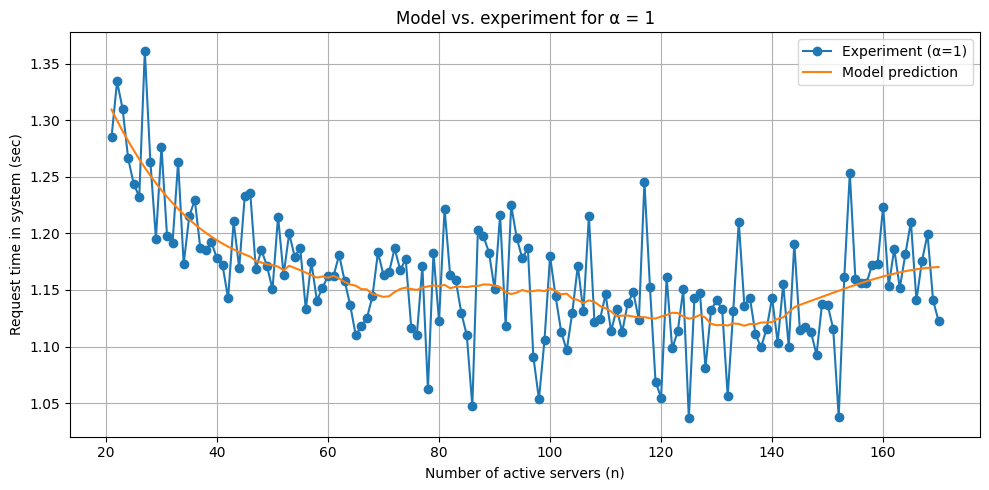

In [19]:
plot_T_for_alpha(1, investigate_df, max_index=150, smooth=True)

In [20]:
import heapq
import random
import numpy as np

def simulate_mm_s(lambda_, mu, n, num_requests=100000, warmup=1000):
    """
    Simulate an M/M/s queue with constant service rate mu.
    Returns the average sojourn time after warmup.
    """
    # Event times
    t = 0.0
    # Event queue: list of (time, type, request_id)
    # type: 0 for arrival, 1 for departure
    event_queue = []
    # Server state
    busy = 0
    # Queue of waiting requests (store arrival time)
    wait_queue = []
    # Statistics
    sojourn_times = []
    request_counter = 0
    served_counter = 0
    
    # Schedule first arrival
    heapq.heappush(event_queue, (t + random.expovariate(lambda_), 0, request_counter))
    request_counter += 1
    
    while served_counter < num_requests + warmup:
        # Get next event
        t, etype, rid = heapq.heappop(event_queue)
        
        if etype == 0:  # Arrival
            # Schedule next arrival
            heapq.heappush(event_queue, (t + random.expovariate(lambda_), 0, request_counter))
            request_counter += 1
            
            # If there is a free server, start service immediately
            if busy < n:
                busy += 1
                # Schedule departure
                service_time = random.expovariate(mu)
                heapq.heappush(event_queue, (t + service_time, 1, rid))
            else:
                # Otherwise, join the queue
                wait_queue.append((rid, t))  # store (id, arrival_time)
        
        else:  # Departure
            # Record sojourn time (if after warmup)
            served_counter += 1
            if served_counter > warmup:
                # We need the arrival time of this request
                # Since we didn't store it for all, we can store it in a dict
                # For simplicity, we'll store arrival time in a dict keyed by rid
                # But we need to get it. Better to store when we schedule.
                pass
            # However, we need the arrival time. Let's restructure.
    
    # Restructure the code to properly store arrival times.

In [21]:
def simulate_mm_s(lambda_, mu, n, num_requests=100000, warmup=1000, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    
    t = 0.0
    event_queue = []  # (time, type, request_id)
    busy = 0
    wait_queue = []   # list of request_ids (FIFO)
    arrival_times = {}  # request_id -> arrival_time
    sojourn_times = []
    request_counter = 0
    served_counter = 0
    
    # Schedule first arrival
    heapq.heappush(event_queue, (t + random.expovariate(lambda_), 0, request_counter))
    arrival_times[request_counter] = t
    request_counter += 1
    
    while served_counter < num_requests + warmup:
        t, etype, rid = heapq.heappop(event_queue)
        
        if etype == 0:  # Arrival
            # Schedule next arrival
            next_arr = t + random.expovariate(lambda_)
            heapq.heappush(event_queue, (next_arr, 0, request_counter))
            arrival_times[request_counter] = t
            request_counter += 1
            
            # Try to start service
            if busy < n:
                busy += 1
                service_time = random.expovariate(mu)
                heapq.heappush(event_queue, (t + service_time, 1, rid))
            else:
                wait_queue.append(rid)
        
        else:  # Departure
            served_counter += 1
            if served_counter > warmup:
                sojourn = t - arrival_times[rid]
                sojourn_times.append(sojourn)
            # Free server and serve next waiting if any
            busy -= 1
            if wait_queue:
                next_rid = wait_queue.pop(0)
                busy += 1
                service_time = random.expovariate(mu)
                heapq.heappush(event_queue, (t + service_time, 1, next_rid))
            # else server idle
    
    # Return average sojourn time
    if sojourn_times:
        return np.mean(sojourn_times)
    else:
        return float('inf')

In [22]:
def simulate_for_config(alpha, n, num_requests=50000, warmup=5000):
    mu = get_mu(n, alpha)
    if mu is None or mu <= 0:
        return None
    return simulate_mm_s(LAMBDA, mu, n, num_requests, warmup)

In [23]:
results = []
for alpha in target_alphas:
    for n in range(21, 694, 20):  # step for speed
        sim_T = simulate_for_config(alpha, n, num_requests=20000, warmup=2000)
        if sim_T is not None:
            results.append((alpha, n, sim_T))

In [24]:
import simpy
import random
import numpy as np

def simulate_mm_s(lam, mu, n, num_requests=30000, warmup=3000, seed=None):
    if seed is not None:
        random.seed(seed)
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=n)
    sojourn_times = []
    served = 0
    done = env.event()
    
    def service(env, arrival_time):
        nonlocal served
        with server.request() as req:
            yield req
            service_time = random.expovariate(mu)
            yield env.timeout(service_time)
            sojourn = env.now - arrival_time
            served += 1
            if served > warmup:
                sojourn_times.append(sojourn)
            if served >= num_requests + warmup:
                done.succeed()
    
    def arrivals():
        while True:
            yield env.timeout(random.expovariate(lam))
            arrival_time = env.now
            env.process(service(env, arrival_time))
    
    env.process(arrivals())
    env.run(until=done)
    
    if sojourn_times:
        return np.mean(sojourn_times)
    else:
        return float('inf')

In [25]:
# Assuming LAMBDA and get_mu are defined
alpha = 0.4
n = 100
mu = get_mu(n, alpha)
T_sim = simulate_mm_s(LAMBDA, mu, n, num_requests=50000, warmup=5000, seed=123)
print(f"Simulated T for α={alpha}, n={n}: {T_sim:.4f} s")

Simulated T for α=0.4, n=100: 1.0936 s


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Import the simulation function (assuming it's defined elsewhere)
# from your_simulation_module import simulate_mm_s

def plot_T_for_alpha(
    alpha,
    experiment_df,
    smooth=True,
    window_length=51,
    polyorder=3,
    max_index=150,
    do_sim=True,
    sim_replications=5,
    sim_requests=30000,
    sim_warmup=3000,
    sim_seed=42,
    sim_max_points=None,   # if None, use all points up to max_index
):
    """
    Plot experimental, analytical, and simulation results for a given alpha.

    Parameters:
        alpha (float): workload mix parameter
        experiment_df (pd.DataFrame): must contain columns 'alpha', 'active_servers_num', 'client_measured_time'
        smooth (bool): apply Savitzky-Golay smoothing to curves
        window_length (int): smoothing window length (must be odd)
        polyorder (int): polynomial order for smoothing
        max_index (int): number of n values to plot (starting from smallest n)
        do_sim (bool): if True, run simulation and add to plot
        sim_replications (int): number of simulation replications per configuration
        sim_requests (int): total requests per simulation run (including warmup)
        sim_warmup (int): warmup requests to discard
        sim_seed (int): base seed for reproducibility (each replication uses seed+rep)
        sim_max_points (int): limit number of simulation points (for performance)
    """
    alpha_df = experiment_df[experiment_df['alpha'] == alpha]
    if alpha_df.empty:
        raise ValueError(f"No experimental data for alpha={alpha}")

    # Sort by number of servers and take first max_index points
    alpha_df = alpha_df.sort_values('active_servers_num')
    x_exp = alpha_df['active_servers_num'].values[:max_index]
    y_exp_raw = alpha_df['client_measured_time'].values[:max_index]

    # Analytical T using your T_sys (which uses mu_dict)
    T_analytical = np.array([T_sys(n, alpha) for n in x_exp])

    # Simulation results
    T_sim = None
    if do_sim:
        # Determine which n values to simulate (limit if needed)
        n_sim_list = x_exp
        if sim_max_points is not None and len(n_sim_list) > sim_max_points:
            # take evenly spaced points
            indices = np.linspace(0, len(n_sim_list)-1, sim_max_points, dtype=int)
            n_sim_list = n_sim_list[indices]

        T_sim_vals = []
        for n in n_sim_list:
            mu = get_mu(n, alpha)   # your interpolation function
            if mu is None or mu <= 0 or mu * n <= LAMBDA:
                T_sim_vals.append(np.nan)
                continue
            # Run multiple replications
            rep_T = []
            for rep in range(sim_replications):
                seed = sim_seed + rep if sim_seed is not None else None
                T = simulate_mm_s(LAMBDA, mu, n,
                                  num_requests=sim_requests,
                                  warmup=sim_warmup,
                                  seed=seed)
                if not np.isinf(T):
                    rep_T.append(T)
            if rep_T:
                T_sim_vals.append(np.mean(rep_T))
            else:
                T_sim_vals.append(np.nan)
        # Create full array aligned with x_exp
        T_sim = np.full_like(x_exp, np.nan, dtype=float)
        # Map simulated values to the corresponding indices
        for i, n in enumerate(x_exp):
            if n in n_sim_list:
                idx = np.where(n_sim_list == n)[0][0]
                T_sim[i] = T_sim_vals[idx]

    # Plotting
    plt.figure(figsize=(10, 5))

    # Experimental data (raw and smoothed)
    if smooth:
        y_exp_smooth = savgol_filter(y_exp_raw, window_length, polyorder)
        plt.plot(x_exp, y_exp_smooth, 'o-', label=f'Experiment (α={alpha})')
        # Also plot raw points lightly for reference
        plt.plot(x_exp, y_exp_raw, 'o', alpha=0.3, markersize=3)
    else:
        # plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, y_exp_raw, 'x', alpha=0.9, markersize=6, color="green", label=f'Experiment (α={alpha})')

    # Analytical model
    if smooth:
        T_analytical_smooth = savgol_filter(T_analytical, window_length, polyorder)
        plt.plot(x_exp, T_analytical_smooth, '-', label='Model (analytical)')
    else:
        # plt.plot(x_exp, T_analytical, '-', label='Model (analytical)')
        T_analytical_smooth = savgol_filter(T_analytical, window_length, polyorder)
        plt.plot(x_exp, T_analytical_smooth, '-', label='Model (analytical)')

    # Simulation results
    if do_sim and T_sim is not None:
        # Remove NaN for plotting
        mask_sim = ~np.isnan(T_sim)
        x_sim = x_exp[mask_sim]
        y_sim = T_sim[mask_sim]
        if len(x_sim) > 0:
            if smooth and len(x_sim) >= window_length:
                # Apply smoothing only if enough points
                y_sim_smooth = savgol_filter(y_sim, min(window_length, len(x_sim)-1 if len(x_sim)%2==1 else len(x_sim)-2), polyorder)
                plt.plot(x_sim, y_sim_smooth, '-', label='Model (simulation)')
            else:
                plt.plot(x_sim, y_sim, 's-', label='Model (simulation)', markersize=4)

    plt.xlabel('Number of active servers (n)')
    plt.ylabel('Request time in system (sec)')
    plt.title(f'Comparison for α = {alpha}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

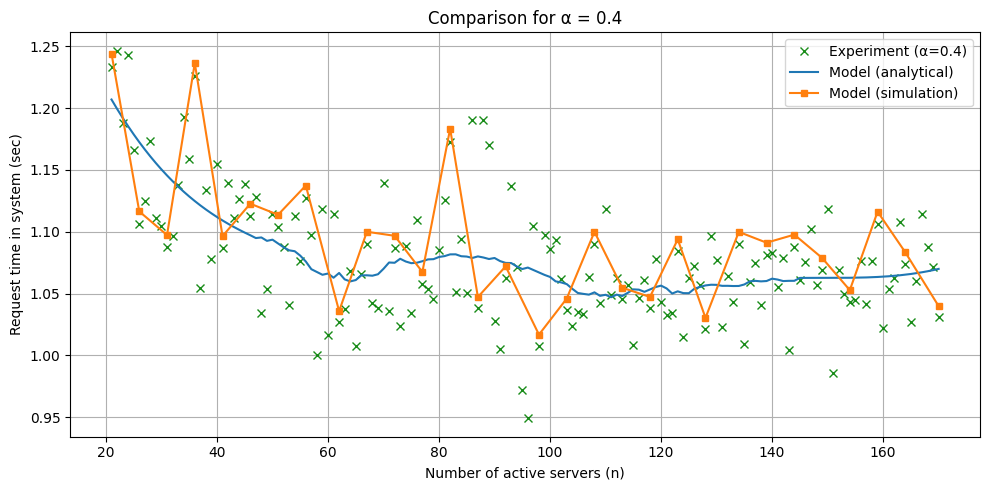

In [27]:
plot_T_for_alpha(
    alpha=0.4,
    experiment_df=investigate_df,
    smooth=False,
    max_index=150,
    do_sim=True,
    sim_replications=3,
    sim_requests=15000,
    sim_warmup=1500,
    sim_max_points=30
)

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def plot_all_alphas(
    experiment_df,
    smooth=True,
    window_length=51,
    polyorder=3,
    max_index=150,
    do_sim=False,
    sim_replications=5,
    sim_requests=30000,
    sim_warmup=3000,
    sim_seed=42,
    sim_max_points=None,
):
    """
    Plot experimental, analytical, and (optional) simulation results
    for all alpha values in a 2x3 grid of subplots.

    Parameters:
        experiment_df (pd.DataFrame): must contain columns 'alpha', 'active_servers_num', 'client_measured_time'
        smooth (bool): apply Savitzky-Golay smoothing to all curves
        window_length (int): smoothing window length (must be odd)
        polyorder (int): polynomial order for smoothing
        max_index (int): number of n values to plot (starting from smallest n)
        do_sim (bool): if True, run simulation and add to each subplot
        sim_replications (int): number of simulation replications per configuration
        sim_requests (int): total requests per simulation run (including warmup)
        sim_warmup (int): warmup requests to discard
        sim_seed (int): base seed for reproducibility
        sim_max_points (int): limit number of simulation points per alpha (performance)
    """
    # Define the six alpha values in increasing order
    alphas = sorted([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # Create figure with 2 rows, 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # For each alpha, extract data and plot
    for idx, alpha in enumerate(alphas):
        ax = axes[idx]
        
        # Filter data for this alpha
        alpha_df = experiment_df[experiment_df['alpha'] == alpha]
        if alpha_df.empty:
            ax.text(0.5, 0.5, f'No data for α={alpha}', ha='center', va='center')
            ax.set_title(f'({idx+1}) α = {alpha}')
            continue
        
        # Sort and slice
        alpha_df = alpha_df.sort_values('active_servers_num')
        x_exp = alpha_df['active_servers_num'].values[:max_index]
        y_exp_raw = alpha_df['client_measured_time'].values[:max_index]
        
        # Analytical T (using your T_sys function)
        T_analytical = np.array([T_sys(n, alpha) for n in x_exp])
        
        # ---- Simulation (if requested) ----
        T_sim = None
        if do_sim:
            n_sim_list = x_exp
            if sim_max_points is not None and len(n_sim_list) > sim_max_points:
                indices = np.linspace(0, len(n_sim_list)-1, sim_max_points, dtype=int)
                n_sim_list = n_sim_list[indices]
            
            T_sim_vals = []
            for n in n_sim_list:
                mu = get_mu(n, alpha)
                if mu is None or mu <= 0 or mu * n <= LAMBDA:
                    T_sim_vals.append(np.nan)
                    continue
                rep_T = []
                for rep in range(sim_replications):
                    seed = sim_seed + rep if sim_seed is not None else None
                    T = simulate_mm_s(LAMBDA, mu, n,
                                      num_requests=sim_requests,
                                      warmup=sim_warmup,
                                      seed=seed)
                    if not np.isinf(T):
                        rep_T.append(T)
                if rep_T:
                    T_sim_vals.append(np.mean(rep_T))
                else:
                    T_sim_vals.append(np.nan)
            # Align with x_exp
            T_sim = np.full_like(x_exp, np.nan, dtype=float)
            for i, n in enumerate(x_exp):
                if n in n_sim_list:
                    idx_n = np.where(n_sim_list == n)[0][0]
                    T_sim[i] = T_sim_vals[idx_n]
        
        # ---- Plotting on this subplot ----
        # Experimental (raw points + smoothed curve)
        if smooth:
            y_exp_smooth = savgol_filter(y_exp_raw, window_length, polyorder)
            ax.plot(x_exp, y_exp_smooth, 'o-', label='Experiment', color="green", linewidth=2)
            ax.plot(x_exp, y_exp_raw, 'o', alpha=0.3, color="green", markersize=3)
        else:
            # ax.plot(x_exp, y_exp_raw, 'o-', label='Experiment')
            ax.plot(x_exp[::8], y_exp_raw[::8], 'x', color="green", markersize=6, label=f'Experiment')
        
        # Analytical model
        T_analytical_smooth = savgol_filter(T_analytical, window_length, polyorder)
        ax.plot(x_exp, T_analytical_smooth, '-', label='Analytical', color="blue", linewidth=2)
        
        
        # Simulation (if available)
        if do_sim and T_sim is not None:
            mask_sim = ~np.isnan(T_sim)
            x_sim = x_exp[mask_sim]
            y_sim = T_sim[mask_sim]
            if len(x_sim) > 0:
                if smooth and len(x_sim) >= window_length:
                    # Ensure window length is odd and <= len
                    win = window_length if window_length % 2 == 1 else window_length + 1
                    win = min(win, len(x_sim) - 1 if len(x_sim) % 2 == 1 else len(x_sim) - 2)
                    if win >= 3:
                        y_sim_smooth = savgol_filter(y_sim, win, polyorder)
                        ax.plot(x_sim, y_sim_smooth, '-', label='Simulation', color="orange", linewidth=2)
                    else:
                        ax.plot(x_sim, y_sim, 's-', label='Simulation', color="orange", markersize=4)
                else:
                    ax.plot(x_sim, y_sim, 's-', label='Simulation', color="orange", markersize=4)
        
        # Subplot formatting
        ax.set_xlabel('Number of servers (n)')
        ax.set_ylabel('Mean response time (s)')
        ax.set_title(f'({idx+1}) α = {alpha}')
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='small')
    
    # Remove any unused subplots (if fewer than 6)
    for j in range(len(alphas), 6):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.savefig('Experimental_Analytical_Simulation.jpeg', bbox_inches='tight', format='jpeg', dpi=400)
    plt.show()

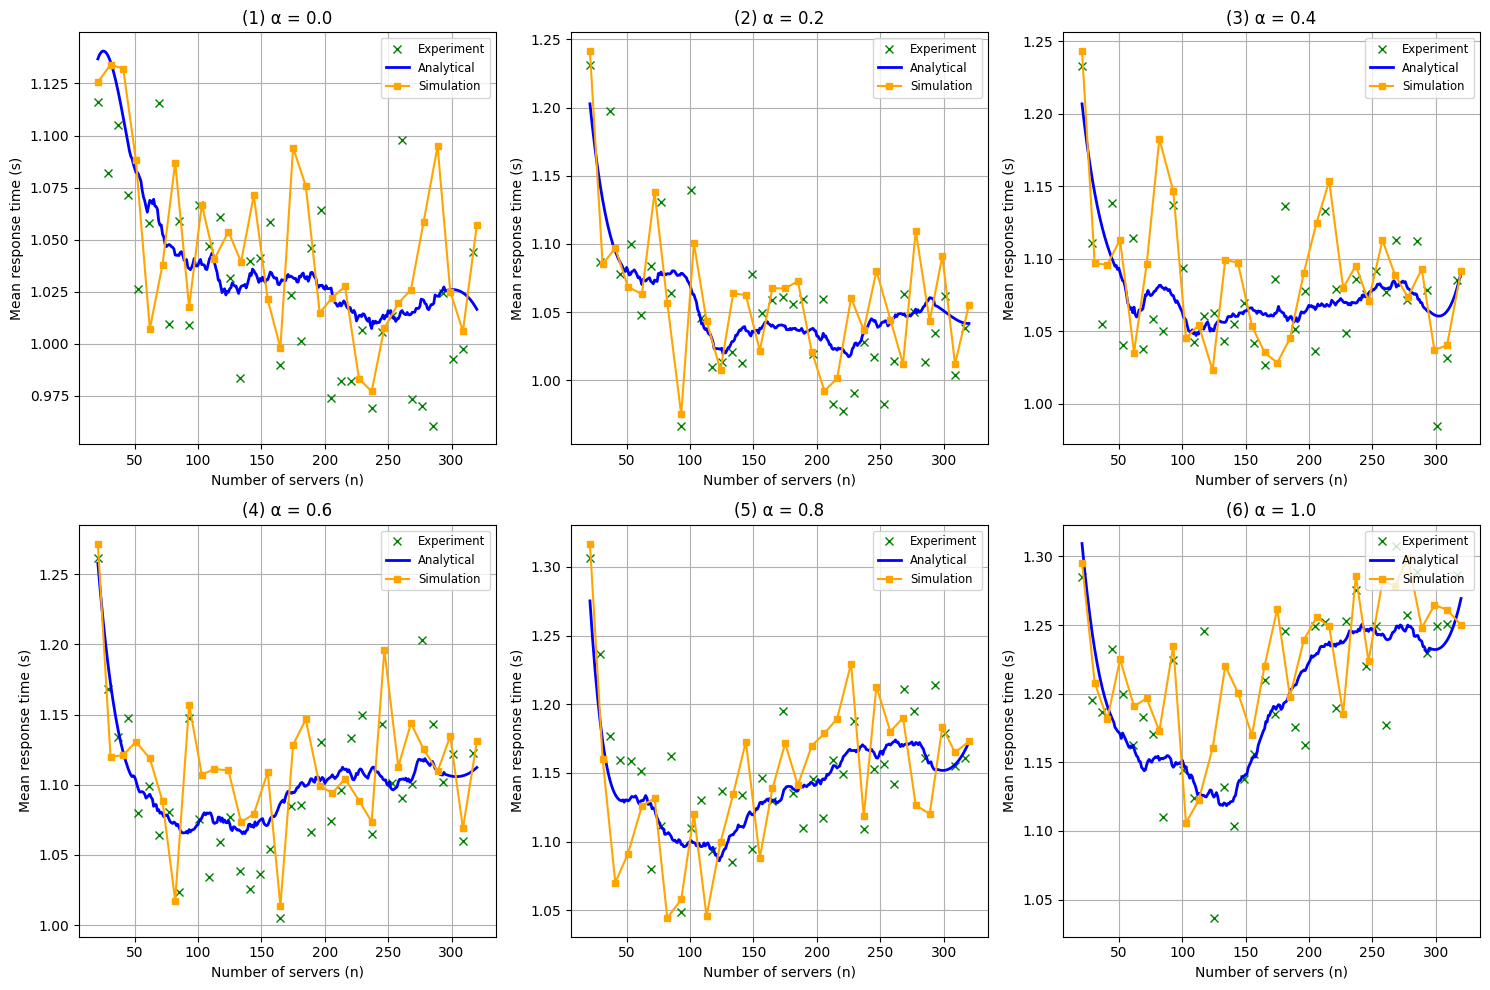

In [57]:
# Assuming LAMBDA, get_mu, T_sys, simulate_mm_s are defined
plot_all_alphas(
    experiment_df=investigate_df,
    smooth=False,
    window_length=51,
    polyorder=3,
    max_index=300,
    do_sim=True,          # Set True to include simulation (will take longer)
    sim_replications=3,
    sim_requests=20000,
    sim_warmup=2000,
    sim_max_points=30
)